# 목적

- 자주 사용되는 Agent Workflow의 두 가지 패턴을 학습합니다.
  - Orchestrator-Worker 패턴
  - Evaluator-optimizer 패턴
<br/>

- Gradio 라는 AI 테스트를 위한 UI 도구를 사용해봅니다.

- [도전] 맛집 여행 플랜을 작성해주는 멋진 AI Application을 만들어봅니다.

# 1. API Key / LangGraph 세팅

먼저 API Key 동작 테스트부터 시작합니다.
- Upstage API Key로 테스트합니다.

In [1]:
import os
from openai import OpenAI

from dotenv import load_dotenv
load_dotenv() # .env파일에서 환경설정 가져오기

# Upstage API
llm = OpenAI(api_key=os.getenv("UPSTAGE_API_KEY"), base_url="https://api.upstage.ai/v1")

model = "solar-pro3"
prompt="KFC 버거 추천좀 해줘, 짧게 두줄로 요약해"

response = llm.chat.completions.create(model=model, messages=[{"role": "user", "content": prompt}])
print(response.choices[0].message.content)

- 바삭한 치킨 필렛에 매콤한 레드‑페퍼 소스를 곁들인 **핫&스파이시 버거**가 가장 인기 있어요.  
- 부드러운 마요네즈와 신선한 양상추를 넣은 **클래식 버거**도 언제나 만족스러운 선택입니다.


### 실습에 필요한 프로그램 설치
- EASY 교안은 LangGraph 1.1 버전 기준으로 설명됩니다.
    - 랭그래프 1.0 이후 부터는 문법이 간결하고 더 쉬워졌습니다.
    - 만약 langchain-upstage 에서 호환되지 않는 버전이라는 Error는 무시합시다.

In [18]:
!pip install -qU langgraph langchain langsmith langchain-openai
!pip install -qU gradio

설치가 잘 되었는지 확인합니다!

설치된 랭체인 / 랭그래프 버전을 확인합니다.
- langchain >= 1.0 이상이면 됩니다.
- langgraph >= 1.0 이상이면 됩니다.

In [19]:
!pip list | grep -E "langgraph |langchain |langchain-openai |langchain-upstage |langsmith "
!pip list | grep "gradio "

langchain                                1.2.13
langchain-openai                         1.1.12
langchain-upstage                        0.7.4
langgraph                                1.1.3
langsmith                                0.7.22
gradio                                   6.10.0
hf-gradio                                0.3.0


### LangSmith - Studio 세팅

이번 역시 LangSmith의 Studio로 실습을 해보시는 것을 권장합니다!
- 시각적으로 보면서 이해하기 좋습니다!
- 여러가지 프롬프트를 입력해보면서 테스트 해볼 수 있습니다!

기억나실까요? PyCharm에다가 세팅하고 서버를 실행했던것이요.

기억이 안나신다면 이전 강의 "LangGraph 개요" 수업자료를 참고해주세요!

### [참고] LangSmith - Trouble Shooting
- 무한루프가 돌거나, 이전 실행결과만 나오는 경우, PyCharm 터미널을 껐다가 재실행하고 다시 터미널에서 아래 명령어를 실행해보세요
```shell
taskkill /F /IM python.exe
```

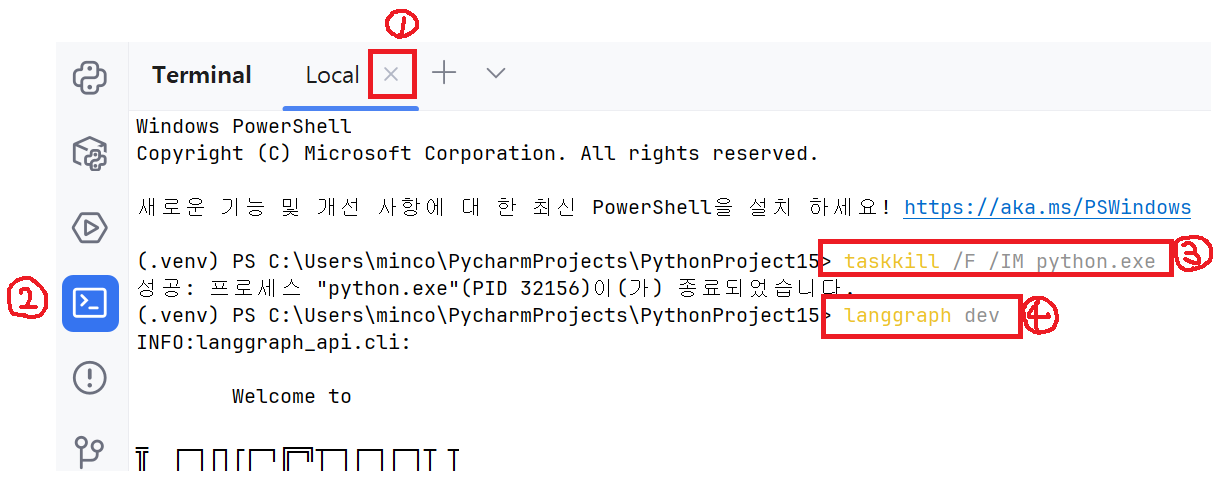

다음은 LangGraph의 기본 Workflow코드입니다. + LLM

아래 코드까지 잘 동작된다면, 수업준비가 다 되었습니다.

In [4]:
from typing_extensions import TypedDict, Annotated
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_upstage import ChatUpstage  # Upstage

from langchain.messages import AnyMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

# ===== LLM =====
load_dotenv() # .env파일에서 환경설정 가져오기

# OpenAI API는 아래 주석을 풀고 쓰세요.
#llm = init_chat_model("gpt-5-nano", temperature=0)

# Upstage API는 아래 주석을 풀고 쓰세요.
llm = ChatUpstage(model="solar-pro", upstage_api_key=os.getenv("UPSTAGE_API_KEY"), temperature=0)


# ===== State =====
class State(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


# ===== Node =====
def BBQ(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# ===== Graph 구성 =====
graph = StateGraph(State)
graph.add_node("BBQ", BBQ)
graph.add_edge(START, "BBQ")
graph.add_edge("BBQ", END)

agent = graph.compile()


# ===== 실행 =====
result = agent.invoke({
    "messages": [HumanMessage(content="KFC랑 맥도날드 치킨 중 뭐가 더 맛있지? 한줄 요약")]
})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

KFC랑 맥도날드 치킨 중 뭐가 더 맛있지? 한줄 요약
================================== Ai Message ==================================

"취향 차이: KFC는 바삭하고 풍부한 맛, 맥도날드 치킨이라면 가벼운 튀김 맛이 특징."


# 2. Orchestrator-Worker 패턴

### 오케스트레이터-워커 패턴이란?

오케스트레이터 워커 패턴은 세 가지 동작으로 구성됩니다.

  - Step1) 작업을 하위 작업으로 분해하고, 일꾼들에게 일을 배정합니다.

  - Step2) 일꾼들(LLM Node)은 각각의 작업을 수행합니다.

  - Step3) 각 일꾼들은 산출물을 종합해서 종합 결과를 만들어냅니다.


Worker Node를 필요한 만큼 생성하고, 각 Worker들은 LLM 작업을 하면 됩니다.

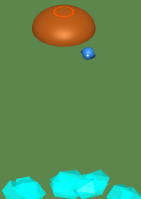

각 단계별 용어와 역할을 암기해주세요!

1. **Orchestrator**
   - 작업 수행 완료를 위해, 필요한 하위작업을 결정합니다.
   - 필요한 개수는 LLM 스스로 조율할 수 있습니다.
2. **Worker**
   - 하위작업 하나를 담당하여, 결과를 만들어냅니다.
   - 어떤 작업을 할지는 Orchestrator에게 전달 받습니다.
3. **Synthesize** (씬서사이즈, 합성)
   - 모든 작업이 끝나기까지 기다린 후, Worker의 결과물을 종합하여 최종 답변을 만들어냅니다.

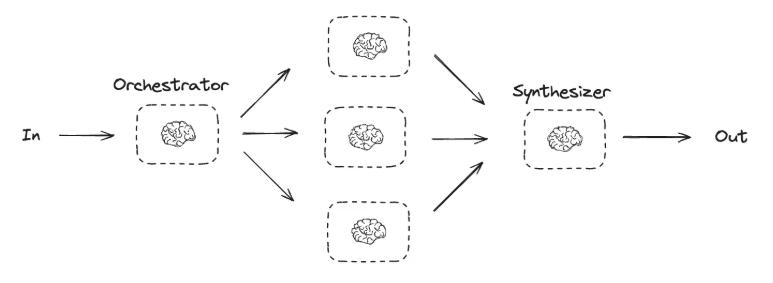

Orchestrator Worker 를 구현하기 위해, 처음으로 사용해야 할 API가 있습니다.
- **Send API** 입니다.
    - Worker 노드를 동적으로 생성한 후, 수행할 명령을 전달합니다.
    - 예시) Send(WorkerNode이름, 전달할명령)


### 예시코드

아래 예시코드의 시나리오는 다음과 같습니다.
  - 책 주제를 입력합니다.
  - Orchestrator는 입력받은 책 주제에 대한 목차를 만듭니다. (2 ~ 5개 챕터로 구성합니다.)
  - 챕터 개수 만큼 Worker Node를 만들고, 각각 챕터의 내용을 완성하게끔 시킵니다.
  - Synthesize는 모든 Worker Node 작업이 종료될 때 까지 기다린 후, 취합하여 최종 책 내용을 만듭니다.

<br/>

특징
 - 각 챕터는 독립적으로 만들어지기에, 이전 챕터의 내용을 알지 못한상태로 내용을 만들게 됩니다.
 - 모든 챕터의 글은 병렬적으로 동시에 만들어집니다.

In [32]:
from typing_extensions import TypedDict, List, Annotated, NotRequired

from pydantic import BaseModel, Field
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_upstage import ChatUpstage  # Upstage

from langchain.messages import AnyMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from dotenv import load_dotenv

# ===== LLM =====
load_dotenv() # .env파일에서 환경설정 가져오기

# OpenAI API는 아래 주석을 풀고 쓰세요.
#llm = init_chat_model("gpt-5-nano", temperature=0)

# Upstage API는 아래 주석을 풀고 쓰세요.
llm = ChatUpstage(model="solar-pro", upstage_api_key=os.getenv("UPSTAGE_API_KEY"), temperature=0)


# ===== Structured Output 준비 =====
class Chapter(BaseModel): 
    name: str = Field(description="챕터의 제목")
    description: str = Field(description="이 챕터에서 다룰 상세 내용과 집필 가이드라인")

class BookPlan(BaseModel): 
    chapters: List[Chapter] = Field(description="책을 구성하는 챕터 리스트")

llm_planner = llm.with_structured_output(BookPlan)


# ===== State 정의 =====
class State(TypedDict):
    topic: str
    chapters: NotRequired[List[Chapter]] # 기획된 챕터 객체들
    completed_chapters: NotRequired[Annotated[list[tuple[int, str]], operator.add]] # (챕터번호, 내용) 저장
    final_report: NotRequired[str]

class WorkerState(TypedDict):
    index: int # 챕터 번호
    chapter: Chapter # 배정된 챕터 객체 (제목 + 가이드라인)
    completed_chapters: Annotated[list[tuple[int, str]], operator.add] # State와 연결용도


## ===== Orchestrator(책 기획을 담당) =====
def orchestrator(state: State):
    topic = state["topic"]
        
    # LLM이 BookPlan 객체를 반환 (Structured Output)
    result = llm_planner.invoke([
        SystemMessage(content="주어진 주제에 대해 2~5개의 챕터로 구성된 전문적인 목차와 집필 계획을 세워라."),
        HumanMessage(content=topic)
    ])
    
    return {"chapters": result.chapters, "completed_chapters": []}


# ====== 병렬 실행 (SendAPI) =====
def assign_workers(state: State):
    return [Send("worker", {"index": i, "chapter": c}) for i, c in enumerate(state["chapters"])]


# ===== worker (책 집필 담당) =====
def worker(state: WorkerState):
    idx = state["index"]
    ch = state["chapter"]

    result = llm.invoke([
        SystemMessage(content="당신은 전문 작가입니다. 제공된 챕터 제목과 가이드라인을 바탕으로 내용을 정확히 3줄로 작성하세요."),
        HumanMessage(content=f"챕터 제목: {ch.name}\n집필 가이드: {ch.description}")
    ])
    
    # 순서 보장을 위해 (인덱스, 내용) 튜플 반환
    return {"completed_chapters": [(idx, result.content)]}


def synthesizer(state: State):
    # 1. 인덱스 번호 순서대로 정렬 (순서 보장)
    sorted_data = sorted(state["completed_chapters"], key=lambda x: x[0])
    
    # 2. 챕터별 내용 취합
    final_contents = []
    full_text_for_title = "" # 제목 생성을 위해 전체 내용을 모을 변수
    
    for idx, content in sorted_data:
        chapter_info = state["chapters"][idx]
        chapter_title = f"## Chapter {idx+1}. {chapter_info.name}"
        section_text = f"{chapter_title}\n\n{content}"
        
        final_contents.append(section_text)
        full_text_for_title += section_text + "\n\n"

    # 3. 전체 내용을 바탕으로 책 제목 생성
    title_result = llm.invoke([
        SystemMessage(content="""작성된 책의 전체 내용을 보고, 독자의 흥미를 끌 수 있는 매력적인 책 제목을 하나만 지어라. 
                      결과는 오직 제목만 출력해라. 따옴표는 제거해라."""),
        HumanMessage(content=f"원래 주제: {state['topic']}\n\n작성된 내용:\n{full_text_for_title}")
    ])
    book_title = title_result.content.strip()

    # 4. 최종 결과물 조립 (제목 + 내용)
    final_report = f"# 제목: {book_title}\n\n" + "\n\n---\n\n".join(final_contents)
    return {"final_report": final_report}

    
# ===== Graph 구성 =====
graph = StateGraph(State)

graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("synthesizer", synthesizer)

graph.add_edge(START, "orchestrator")
graph.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["worker"],
)
graph.add_edge("worker", "synthesizer")
    graph.add_edge("synthesizer", END)

agent = graph.compile()


# === 실행 ===
result = agent.invoke({"topic": "아이언맨과 스파이더맨이 전투를 하는 소설"})

print(result["final_report"])

# 제목: 강철과 거미줄의 동맹: 아이언맨 vs 스파이더맨

## Chapter 1. 충돌의 서막: 기술 유출과 정체성 위기

토니 스타크는 자신의 첨단 기술이 유출되어 빌런들에게 악용되자 분노하며, 피터를 의심하며 대립한다. 피터 파커는 기술 유출의 누명을 쓰며 정체성 혼란과 책임감을 동시에 겪는 내적 갈등에 빠진다. 두 영웅은 서로의 신념과 신뢰를 시험받으며, 기술 남용과 도덕적 책임에 대한 첨예한 대립을 펼친다.

---

## Chapter 2. 맨해튼의 격전: 강철과 거미줄의 충돌

1. 맨해튼 한복판에서 강철 아머와 웹슈터의 첫 교전이 폭발하며, 고층 빌딩 사이를 가로지르는 격투는 시가지를 초토화시키고 무고한 시민들의 비명을 자아낸다.  
2. "이건 전쟁이야!" 스파이더맨의 웹슈터가 아머의 관절부를 노릴 때마다, 아이언맨의 리펄서 빔은 아스팔트를 녹이며 기술적 대결의 긴장감을 고조시킨다.  
3. 전투의 여파 속에서 부서진 소방차와 대피하는 시민들 사이로, 두 영웅은 "다음엔 민간인을 먼저 생각하라"는 냉정한 경고를 교환하며 각자의 길을 떠난다.

---

## Chapter 3. 마스크 뒤의 인간: 대립에서 이해로

전투의 침묵 속에서 토니는 과거의 유령과 마주하고, 피터는 무너진 도시 앞에서 책임감을 되묻는다. 철갑과 거미줄 뒤에 숨은 상처를 드러내며, 그들은 '영웅'이라는 가면 너머의 인간을 발견한다. "우리는 적이 아니라 같은 상처를 나눈 형제였다"는 토니의 고백에 피터가 고개를 끄덕이는 순간, 대립의 장막에 빛이 스며든다.

---

## Chapter 4. 새로운 동맹: 융합과 재탄생의 순간

1. 빌런의 등장으로 적대 관계였던 두 팀이 공동의 적을 막기 위해 아머-웹슈터 하이브리드 시스템을 개발하며 협력 구도를 형성한다.  
2. 기술과 팀워크를 융합한 새로운 전략으로 클라이맥스에서 빌런의 초강력 무기를 무력화시키며 극적인 승리를 이끌어낸다.  
3. 전투 후, 서로의 차이를 인정하며 진정한 동맹으로 재탄생하는 캐릭터들의 성장을 긴장감

### LangSmith - Studio에서 결과 확인하기

LangSmith - Studio에서 각각의 Step별 Message들을 확인해볼 수 있습니다.

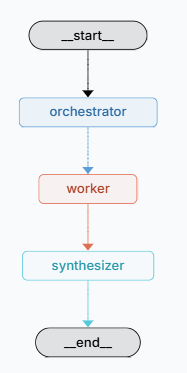

# 3. Plan-and-Excute 패턴 (Sequential Orchestrator worker 패턴)

### Plan-and-Excute 패턴이란?

Orchestrator-Worker 패턴에서 Orchestrator에게 순차적인 작업 Plan을 세우도록 할 수 있습니다.

기존에 다루었던 패턴은 Orchestrator가 작은 작업으로 나누어, 모두 병렬로 일을 하는 구조였습니다.

하지만 음식 레시피의 각 Step을 병렬로 수행하면 안되겠죠!?

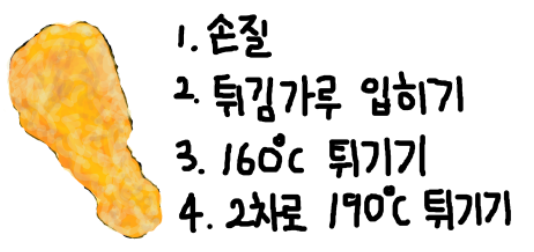

Plan으로 Step1, 2, 3, ... 와 같은 절차를 만들겠습니다.
- LLM이 스스로 Step의 개수와 절차를 결정할 것입니다.

이후 각 절차를 순차적으로 수행합니다.

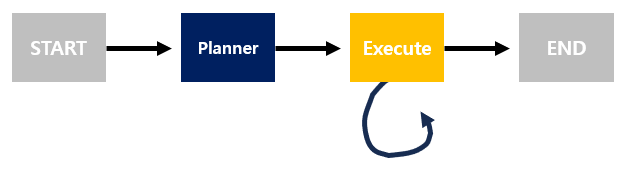

### 예시코드

In [36]:
from typing_extensions import TypedDict, List, Annotated, NotRequired

from pydantic import BaseModel, Field
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_upstage import ChatUpstage  # Upstage

from langchain.messages import AnyMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from dotenv import load_dotenv

# ===== LLM =====
load_dotenv() # .env파일에서 환경설정 가져오기

# OpenAI API는 아래 주석을 풀고 쓰세요.
#llm = init_chat_model("gpt-5-nano", temperature=0)

# Upstage API는 아래 주석을 풀고 쓰세요.
llm = ChatUpstage(model="solar-pro", upstage_api_key=os.getenv("UPSTAGE_API_KEY"), temperature=0)


# ===== Structured Output 준비 =====
class Step(BaseModel):
    title: str = Field(description="이번 Step의 명칭")
    instruction: str = Field(description="이전 결과물을 바탕으로 수행해야 할 구체적인 작업 지침")

class Plan(BaseModel):
    steps: List[Step] = Field(description="음식 제작을 위한 순차적 단계 리스트")

planner_llm = llm.with_structured_output(Plan)


# ===== State =====
class State(TypedDict):
    topic: str # 음식 이름
    steps: NotRequired[List[Step]] # 기획된 Step 객체들
    current_idx: NotRequired[int]  # 몇 번째 단계의 Work인지 확인용 Index
    context: NotRequired[str] # 이전 작업 결과가 누적되는 저장소


# ===== Planner(기획자) =====
def planner(state: State):
    result = planner_llm.invoke([
            SystemMessage(content="주어진 주제를 해결하기 위해 순서가 중요한 2~5단계의 정밀한 계획을 세워라."),
            HumanMessage(content=state["topic"])
        ])
    
    return {
        "steps": result.steps,
        "current_idx": 0,
        "context": "--- [조리 시작] ---"
    }


# ===== Execute Node (직렬 실행) =====
def execute_step(state: State):
    curr_idx = state["current_idx"]
    step_info = state["steps"][curr_idx]
    
    # 이전 단계의 context를 참고하여 현재 단계를 수행
    response = llm.invoke([
        SystemMessage(content=f"당신은 전문 요리사입니다. 이전까지의 과정을 바탕으로 다음 단계를 완성하세요."),
        HumanMessage(content=f"""
[지금까지 진행된 상황]:
{state['context']}

[이번에 수행할 작업]:
단계명: {step_info.title}
상세 지침: {step_info.instruction}

위 지침에 따라 결과를 3줄 내외로 작성하세요.
""")
    ])
    
    # 생성된 결과 누적
    step_result = f"\n\n### {curr_idx + 1}. {step_info.title}\n{response.content}"
    
    return {
        "context": state["context"] + step_result,
        "current_idx": curr_idx + 1
    }


# ===== 종료 조건 확인 =====
def should_continue(state: State):
    # Orchestrator가 기획한 Step 개수가 넘어가면 종료
    if state["current_idx"] < len(state["steps"]):
        return "execute_step"
    return END


# ===== Graph 구성 =====
graph = StateGraph(State)

graph.add_node("planner", planner)
graph.add_node("execute_step", execute_step)

graph.add_edge(START, "planner")
graph.add_edge("planner", "execute_step")

graph.add_conditional_edges(
    "execute_step",
    should_continue,
    {
        "execute_step": "execute_step", 
        END: END
    }
)

agent = graph.compile()


# ===== 실행 =====
result = agent.invoke({"topic": "KFC 스타일 프라이드 치킨 레시피"})
print(result["context"])

--- [조리 시작] ---

### 1. 재료 준비 및 숙성
1. 닭다리, 날개, 가슴살을 균일한 크기로 분할한 후 깨끗한 키친타월로 표면의 물기를 제거합니다.  
2. 준비한 닭 부위를 버터밀크에 완전히 잠기도록 담근 후 냉장고에서 12시간 이상 숙성시켜 부드러운 식감과 깊은 풍미를 형성합니다.  
3. 숙성 완료 후 닭을 건져내어 체에 밭쳐 과잉 버터밀크를 제거한 뒤 다음 조리 단계로 진행합니다.

### 2. 시즈닝 및 튀김옷 입히기
1. 체에 밭쳐 물기를 뺀 닭을 준비한 시즈닝 혼합물(밀가루, 파우더드 밀크, 마늘 가루, 파프리카 가루, 흰 후추, 소금)에 넣고 골고루 뒤집어 코팅합니다.  
2. 닭 표면에 시즈닝이 균일하게 묻도록 가볍게 털어낸 후, 남은 가루는 체로 걸러 추가로 덧발라 바삭한 식감을 강화합니다.  
3. 최종적으로 닭을 10분간 휴지시켜 시즈닝이 밀착되도록 한 후 튀김 또는 오븐 조리로 진행합니다.

### 3. 2단계 튀김 공정
1. 170~180°C로 예열된 식용유에 닭을 넣고 12~15분간 1차 튀긴 후, 키친타월 위에 올려 5분간 기름기를 제거합니다.  
2. 다시 180°C로 가열된 기름에 닭을 넣어 3~4분간 2차 튀겨 황금빛 크러스트와 바삭한 식감을 완성합니다.  
3. 튀긴 닭은 즉시 서빙하거나, 종이포일로 덮어 5분간 휴지시켜 내부 육즙을 고르게 분배합니다.

### 4. 최종 시즈닝 및 서빙
1. 튀긴 닭을 종이 타월로 가볍게 눌러 잔여 기름을 제거한 후, 미리 혼합한 KFC 스파이시 파우더를 골고루 뿌려 풍미를 강화합니다.  
2. 파우더가 닭 표면에 고르게 달라붙도록 가볍게 흔들어 준 뒤, 즉시 서빙 접시에 담아 바삭한 식감을 유지합니다.  
3. 추가로 허니 갈릭 딥 소스나 레몬 웨지를 곁들여 맛의 밸런스를 완성합니다.


### LangSmith에서 결과 확인

Studio에서 Plan의 상세 내용을 확인할 수 있습니다.

Plan을 어떻게 세우는지 살펴봐주세요.

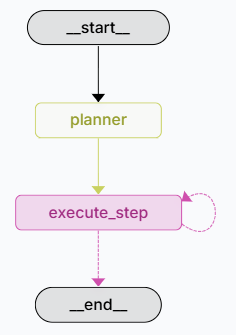

### [참고] Orchestrator-Workers 패턴은, Agent Workflow의 공식 명칭이 맞나요?

참고로 Agent Workflow 패턴들의 명칭은 통일되지 않았습니다.
  - 암묵적으로는... 구글, OpenAI, 엔트로픽(클로드)에서 공식 기술자료를 만들어 용어를 사용하면, 그게 공식 명칭으로 간주 되는것이죠.

LangGraph에서는 Plan-and-Excute라는 이름을 썼었고 (지금은 기술 블로그 내용이 삭제되었어요.)

엔트로픽은 순차적으로 실행하는 것도 Orchestrator-Workers 패턴으로 취급하곤 합니다.
  - https://platform.claude.com/cookbook/patterns-agents-orchestrator-workers

지금까지 순차적으로 Plan을 세워서 실행하는 패턴을 학습했습니다.

# 4. Evaluator-Optimizer 패턴

### Evaluator-Optimizer 패턴이란?

Evaluator-Optimizer는 LLM에게 평가자를 붙여서, 성능을 개선시키는 방법입니다.

사례를 보도록 하겠습니다.

아래 그램과 같이 Workflow를 구성했지만, 간헐적으로 LLM이 답변을 잘 수행 못하는 경우가 있습니다.

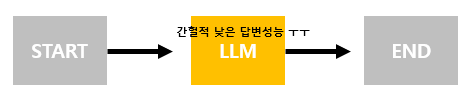

이런 경우 LLM이 그대로 답변하는 것이 아니라,

평가해주는 LLM을 추가로 붙여주면 일관된 답변 품질을 유지할 수 있습니다.

  - Optimizer가 제대로 답변했는지 Evaluator가 확인합니다.
  - 제대로 답변했다면 그대로 답변을 제출합니다.
  - 마음에 들지 않는다면, 피드백과 함께 다시 답변을 시킵니다.

간단하죠?

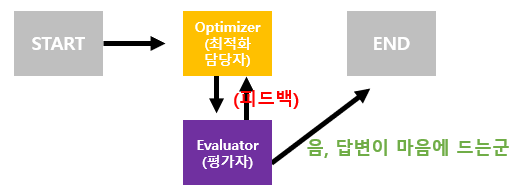

Optimizer가 만든 질문을, Evaluator가 계속 마음에 안든다고 하면 어떻게 하나요?

최대 피드백 횟수를 정해두면 됩니다.

최대 피드백을 넘어가면 어쩔수없이 마지막 답변을 전달합니다.

### 다양한 용어

이 용어는 LangGraph / Claude 모두 쓰는 용어입니다.
  - https://claude.com/blog/common-workflow-patterns-for-ai-agents-and-when-to-use-them
  - https://docs.langchain.com/oss/python/langgraph/workflows-agents
  - 구 이름은 "Reflection 패턴" 입니다.

### Evaluator-Optimizer 장점과 단점

장점
  - LLM 품질이 일관되게 나올 수 있습니다.

단점
  - LLM 사용비용이 배로 나와요.
  - 답변이 마음에 안들어 Loop를 돌 때 마다 시간이 소요됩니다.

꼭 중요한 곳에만 쓰면 되겠죠?

### Evaluator 모델은 Optimizer 보다 성능이 더 좋은 모델을 써야하나요?

- 비용만 허락한다면, 그러는 것이 좋습니다.
  - 보통 출력토큰보다 입력 토큰비용이 저렴하기 때문에, 비용 계산해서 선택하시면 될겁니다.
- 비용을 아끼려면, 같은 성능의 모델을 써도 됩니다.

### 코드 분석하기 (Loop 제한 없는 코드)

입력받은 주제에 대해 농담을 만들어내는 LLM 입니다.

재미있는 얘기로 평가될 때 까지 Optimizer는 지속적으로 새로운 농담을 만들어냅니다.

In [91]:
from typing_extensions import TypedDict, List, Annotated, NotRequired
from typing import Literal

from pydantic import BaseModel, Field
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_upstage import ChatUpstage  # Upstage

from langchain.messages import AnyMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from dotenv import load_dotenv

# ===== LLM =====
load_dotenv() # .env파일에서 환경설정 가져오기

# OpenAI API는 아래 주석을 풀고 쓰세요.
#llm = init_chat_model("gpt-5-nano", temperature=0)

# Upstage API는 아래 주석을 풀고 쓰세요.
llm = ChatUpstage(model="solar-pro", upstage_api_key=os.getenv("UPSTAGE_API_KEY"), temperature=0)


# ===== State =====
class State(TypedDict):
    topic: str
    joke: NotRequired[str]
    feedback: NotRequired[str]
    funny_or_not: NotRequired[str]


# ===== Structured Output 준비 =====
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="농담이 재밌는지, 재미가 없는지 결정한다.",
    )
    feedback: str = Field(
        description="농담이 재미 없는 경우, 어떻게 하면 더 재미있을지 피드백을 제공한다.",
    )
    
llm_evaluator = llm.with_structured_output(Feedback)


# ===== Generator(Optimizer) Node =====
def llm_call_generator(state: State):    
    prompt = f"{state['topic']}에 관련되어 웃긴 농담 1개만 해줘 (3줄 이내)\n"
    
    if state.get("feedback"):
        prompt += f"이전에 너가 시도했던 농담의 피드백인데, 반영해줘 : {state['feedback']}"

    result = llm.invoke(prompt)
    return {"joke": result.content}


# ===== Evaluator Node =====
def llm_call_evaluator(state: State):
    grade = llm_evaluator.invoke(f"다음 농담에 대해 재미있는지 판별해줘 : {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# ===== 조건 분기 ======
def route_joke(state: State):
    if state["funny_or_not"] == "funny":
        return "Accepted"

    return "Rejected + Feedback"


# ===== Graph 생성 =====
graph = StateGraph(State)

graph.add_node("generator", llm_call_generator)
graph.add_node("evaluator", llm_call_evaluator)

graph.add_edge(START, "generator")
graph.add_edge("generator", "evaluator")
graph.add_conditional_edges(
    "evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "generator",
    },
)

agent = graph.compile()

state = agent.invoke({"topic": "KFC 햄버거"})
print(state["joke"])

KFC 햄버거가 너무 맛있어서  
먹다가 닭다리 대신 내 다리를 뜯을 뻔했어.  
(치킨이 아니라 햄버거를 주문한 건 안 비밀) 🍗😂


### 제한 반복 횟수를 추가한 코드

무한루프를 방지하기 위해 제한 반복횟수를 추가하였습니다.

In [94]:
from typing_extensions import TypedDict, List, Annotated, NotRequired
from typing import Literal

from pydantic import BaseModel, Field
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_upstage import ChatUpstage  # Upstage

from langchain.messages import AnyMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from dotenv import load_dotenv

# ===== LLM =====
load_dotenv()  # .env파일에서 환경설정 가져오기

# OpenAI API는 아래 주석을 풀고 쓰세요.
# llm = init_chat_model("gpt-5-nano", temperature=0)

# Upstage API는 아래 주석을 풀고 쓰세요.
llm = ChatUpstage(model="solar-pro", upstage_api_key=os.getenv("UPSTAGE_API_KEY"), temperature=0)


# ===== State =====
class State(TypedDict):
    topic: str
    joke: NotRequired[str]
    feedback: NotRequired[str]
    funny_or_not: NotRequired[str]
    iteration: NotRequired[int]


# ===== Structured Output =====
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="농담이 재밌는지, 재미가 없는지 결정한다.",
    )
    feedback: str = Field(
        description="농담이 재미 없는 경우, 어떻게 하면 더 재미있을지 피드백을 제공한다.",
    )


llm_evaluator = llm.with_structured_output(Feedback)

# ===== Init Node =====
def initialize(state: State):
    return {
        "iteration": 0
    }


# ===== Generator(Optimizer) Node =====
def llm_call_generator(state: State):
    prompt = f"{state['topic']}에 관련되어 웃긴 농담 1개만 해줘 (3줄 이내)\n"

    if state.get("feedback"):
        prompt += f"이전에 너가 시도했던 농담의 피드백인데, 반영해줘 : {state['feedback']}"

    result = llm.invoke(prompt)

    return {
        "joke": result.content,
        "iteration": state["iteration"] + 1  # 반복 증가
    }


# ===== Evaluator =====
def llm_call_evaluator(state: State):
    grade = llm_evaluator.invoke(f"다음 농담에 대해 재미있는지 판별해줘 : {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# ===== Router =====
def route_joke(state: State):
    # 1. 성공 조건
    if state["funny_or_not"] == "funny":
        return "Accepted"

    # 2. 반복 횟수 초과 (3회 제한)
    if state["iteration"] >= 3:
        return "Max Iteration Reached"

    # 3. 다시 생성
    return "Rejected + Feedback"


# ===== Graph 생성 =====
graph = StateGraph(State)

graph.add_node("initialize", initialize) # 초기화 노드
graph.add_node("generator", llm_call_generator)
graph.add_node("evaluator", llm_call_evaluator)

graph.add_edge(START, "initialize")
graph.add_edge("initialize", "generator")
graph.add_edge("generator", "evaluator")

graph.add_conditional_edges(
    "evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "generator",
        "Max Iteration Reached": END,
    },
)

agent = graph.compile()

# ===== 실행 =====
result = agent.invoke({
    "topic": "KFC 햄버거"
})

print(result["joke"])
print()
print("[Feedback]")
print(result["feedback"])
print()
print("iteration:", result["iteration"])
print("result:", result["funny_or_not"])

KFC 햄버거가 너무 맛있어서  
닭다리 살까지 탈골했다는 소문이...  
(사실 그건 '치킨'이지 '햄버거'가 아니라고요!) 🍗😂

[Feedback]
농담의 유머 포인트가 명확하지만, '탈골'이라는 표현이 다소 과격할 수 있어 일부 청중에게는 불쾌감을 줄 수 있습니다. 대신 '닭다리까지 다 먹어버렸다'는 식의 표현을 사용하면 더 부드럽고 대중적인 유머가 될 수 있을 것 같습니다. 또한 '치킨'과 '햄버거'의 대비를 강조하는 결말이 효과적이었습니다.

iteration: 1
result: funny


### LangSmith에서 결과 확인

피드백 내용을 상세히 확인할 수 있습니다.

Studio에서 피드백을 살펴봐주세요.

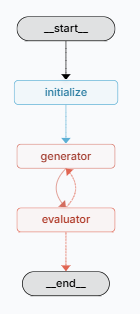

# 5. Gradio UI 소개

### Gradio 소개
- Python 기반 머신러싱 모델의 **데모 App**을 만들기 위한 오픈소스 패키지 입니다.
  - **몇 초만에 Web Application의 URL을 생성할 수 있습니다.**
  - 코랩에 내장되어있습니다. 별도 설치가 필요하지 않습니다.

- 아래이미지는 gradio UI 동작 예시입니다.
  - 이미지 출처 : https://www.gradio.app/guides/quickstart

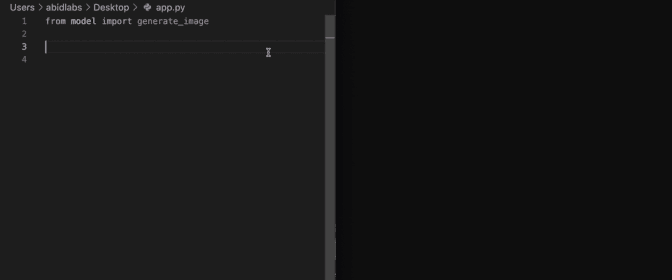

### Gradio 설치

아래 명령어를 실행하여 gradio를 설치합시다.

In [10]:
!pip install -qU gradio
!pip list | grep "gradio "

gradio                                   6.10.0
hf-gradio                                0.3.0


### Gradio 기본코드

- 기본 코드를 실행하기 전에, 아래 코드를 실행해주세요.
  - 코랩에서 재실행 속도를 높혀주는 확장도구입니다.

- 아래는 Gradio 공식 Hello world 코드입니다.
- 강도 스크롤을 높일수록 "!" 가 늘어납니다.
  - 코드 출처 : https://www.gradio.app/guides/quickstart#building-your-first-demo

- 외부에서 접속가능한 URL도 나오는데, 1주일간 무료입니다.

  - 한번 클릭해보세요.

In [97]:
import gradio as gr

def greet(name, intensity):
    return "Hello, " + name + "!" * int(intensity)

demo = gr.Interface(
    fn=greet,
    inputs=["text", "slider"],
    outputs=["text"],
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7867
* Running on public URL: https://25e2d555e10460c26f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 6. 랭그래프와 Gradio 연동 샘플코드


랭그래프 기본코드와 Gardio를 연동해봅시다.

### 랭그래프 + Gardio 대화창 코드
-  Gradio 코드 안에 랭그래프의 invoke 함수를 넣으면 끝입니다.

In [5]:
from typing_extensions import TypedDict, Annotated
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_upstage import ChatUpstage  # Upstage

from langchain.messages import AnyMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver # InMemorySaver : 세션별 데이터를 저장하기 위한 기능
from dotenv import load_dotenv

# ===== LLM =====
load_dotenv() # .env파일에서 환경설정 가져오기

# OpenAI API는 아래 주석을 풀고 쓰세요.
#llm = init_chat_model("gpt-5-nano", temperature=0)

# Upstage API는 아래 주석을 풀고 쓰세요.
llm = ChatUpstage(model="solar-pro", upstage_api_key=os.getenv("UPSTAGE_API_KEY"), temperature=0)


# ===== State =====
class State(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


# ===== Node =====
def BBQ(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# ===== Graph 구성 =====
graph = StateGraph(State)
graph.add_node("BBQ", BBQ)
graph.add_edge(START, "BBQ")
graph.add_edge("BBQ", END)

agent = graph.compile()


# ===== 단기기억 메모리 추가 ======
checkpointer = InMemorySaver() # checkpointer = 저장공간
agent = graph.compile(checkpointer=checkpointer) 

config = {"configurable": {"thread_id": "user1"}} # user1님의 대화이력으로 저장할 예정



# ===== 실행(동작 테스트) =====
#result = agent.invoke({"messages": [HumanMessage(content="KFC랑 맥도날드 치킨 중 뭐가 더 맛있지? 한줄 요약")]})

#for m in result["messages"]:
#    m.pretty_print()

In [15]:
import gradio as gr
from langchain_core.messages import HumanMessage

# 1. 채팅 처리 함수
def chat(user_input, history):
    # LangGraph 실행 (입력값 전달)
    result = agent.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config={"configurable": {"thread_id": "user_1"}}
    )
    
    ai_reply = result["messages"][-1].content
    
    history.append({"role": "user", "content": user_input})
    history.append({"role": "assistant", "content": ai_reply})
    return history, ""

# 2. UI 구성
with gr.Blocks() as demo:
    gr.Markdown("### 🍗 LangGraph 챗봇")
    
    with gr.Row():
        # --- 왼쪽: 입력 영역 ---
        with gr.Column(scale=1):
            msg = gr.Textbox(
                label="질문 입력", 
                placeholder="내 이름은 KFC, 탐정이죠 제 이름을 기억해주세요.",
                lines=3
            )
            submit_btn = gr.Button("🚀 전송", variant="primary")

        # --- 오른쪽: 대화 이력 (높이 400) ---
        with gr.Column(scale=2):
            chatbot = gr.Chatbot(label="대화 이력", height=400)

    # 이벤트 연결 (엔터 및 버튼 클릭)
    msg.submit(chat, [msg, chatbot], [chatbot, msg])
    submit_btn.click(chat, [msg, chatbot], [chatbot, msg])

# 3. Gradio 실행
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7864
* Running on public URL: https://86f85c12f0652a5f9c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 7. Gradio UI를 Vibe 코딩으로 꾸미기

- 손쉽게 UI를 꾸밀 수 있도록 Gradio에서 바이브코딩 기능을 제공합니다!
- Gradio를 따로 공부하지 않아도, 쉽게 UI를 꾸미고 적용할 수 있습니다.

PyCharm에서 코드를 실행해야합니다!
- **ui.py 파일**을 하나 생성한 후, 아래 기본 코드를 넣어둡시다.

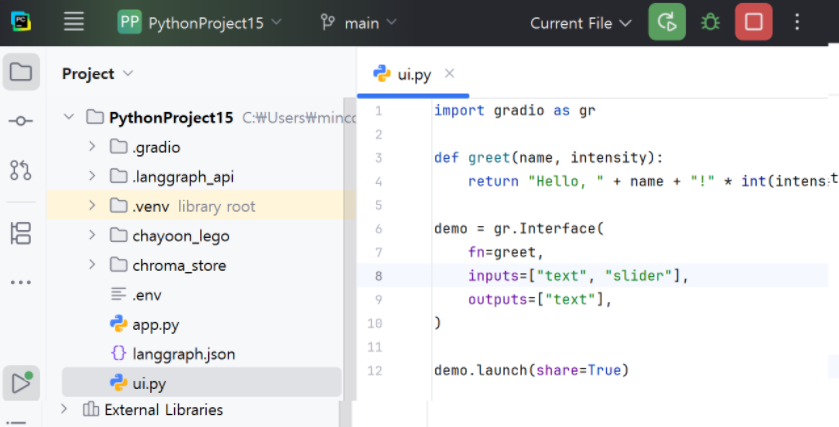

```python
import gradio as gr

def greet(name, intensity):
    return "Hello, " + name + "!" * int(intensity)

demo = gr.Interface(
    fn=greet,
    inputs=["text", "slider"],
    outputs=["text"],
)

demo.launch(share=True)
```

### 허깅페이스 키 발급받기
- Gradio는 허깅페이스가 소유한 Library 이기에, 허깅페이스에서 키를 발급받고 써야합니다.
- 허깅페이스 사이트에 접속하고, KEY를 발급 받습니다.

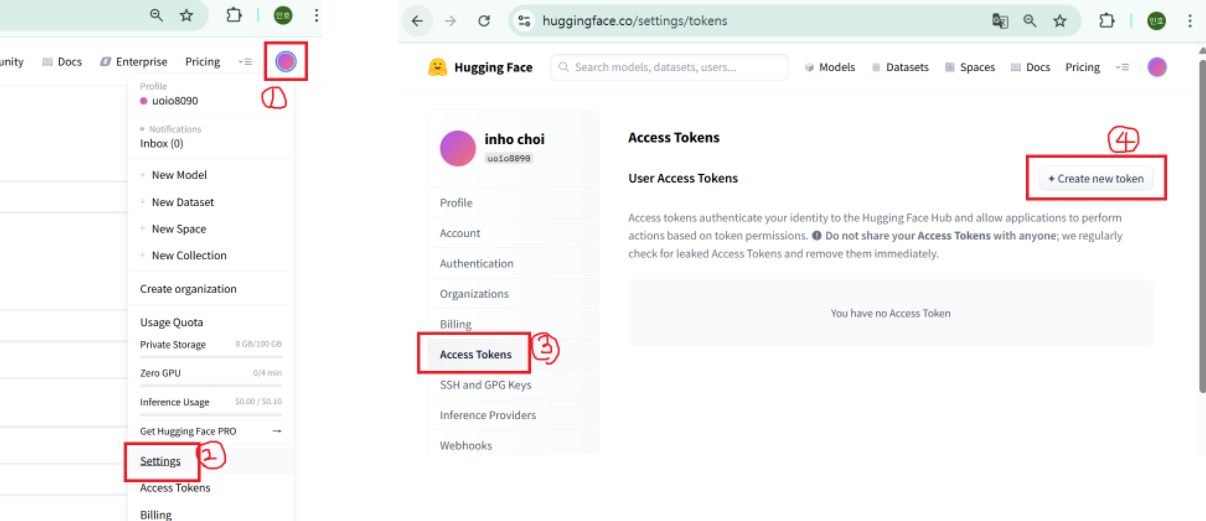

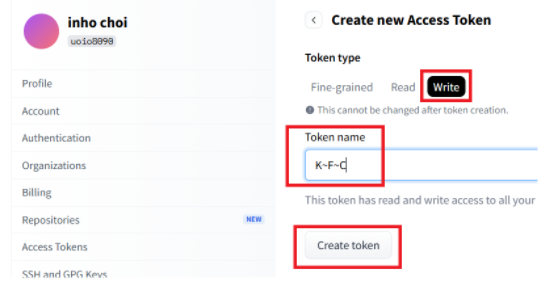

write 권한을 주면 됩니다.

생성된 KEY는 메모장에 잠시 백업해둡시다.
  - .env에 기록하지 않아도 됩니다.

### gradio 설치 및 바이브 코딩 실행

아래 명령어를 터미널에 입력하여, gradio를 설치합니다.

```shell
pip install -U gradio
```

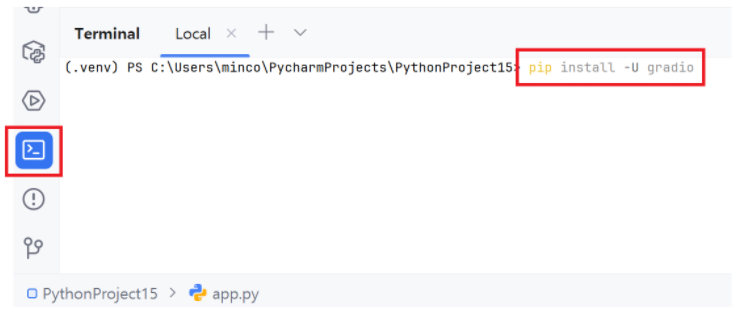

이후 바이브모드로 gradio를 실행합니다.

```shell
gradio --vibe ui.py
```

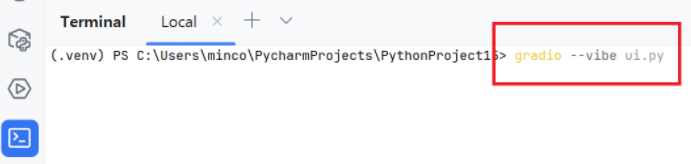

아래와 같이 질문이 들어옵니다.
  - Enter your token : **허깅페이스 키 입력**
  - Add token as git credential? (허깅페이스의 Git도 사용할텐가?) : **n 입력**
  - Stay logged in to Hugging Face? (로그인 유지할텐가?) : **Y 입력**

이후 URL이 나오면 클릭합니다.

- 실행결과는 다음과 같습니다.
- 프롬프트를 입력하여 꾸며주세요.
  - 예시
    - 화면을 최소한의 기본 챗봇 채팅화면으로 꾸며
    - TextBox 하나 더 추가해봐
    - 대화창 크기를 줄여줘

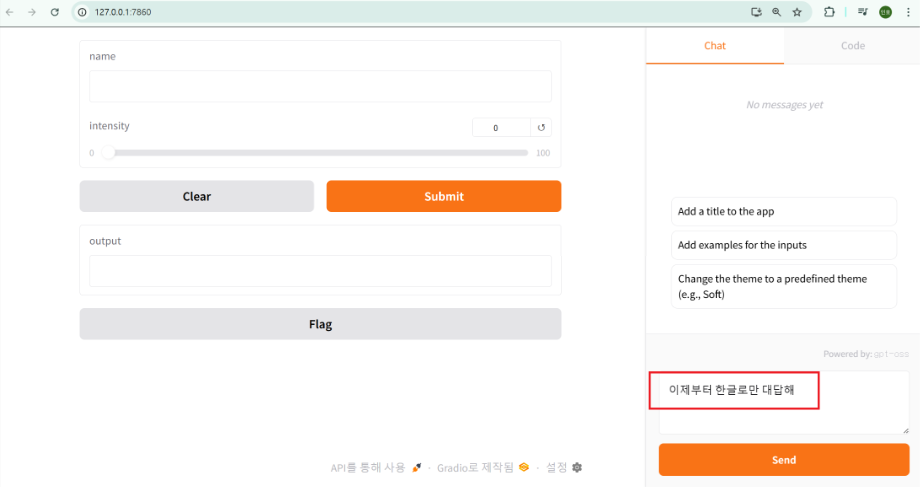

이후 "Code"를 누르면 지금까지 꾸민 UI의 소스코드가 나옵니다.

이렇게 꾸민 UI의 소스코드에

랭그래프 샘플코드를 넣으면, 나만의 AI Application을 제작할 수 있습니다.

# 8. [도전] 맛집 여행 플래너 서비스 개발
- 나만의 AI Agent Workflow를 가진 AI Application을 만들어보는 미션입니다.
- 기존 실습자료를 참고하여 만들어보세요.

### 미션 1 - Workflow 개발
  - Workflow를 어떻게 구현할지 설계해보세요.
  - Orchestrator-Worker 패턴을 사용해주세요.
  - 최종 결과를 취합하는 LLM에 Evaluator-Optimizer 패턴을 적용해주세요.

### 미션 2 - Gradio UI와 연동하기
- 이제 멋지게 화면을 구성할 차례입니다.
- Vibe 코딩으로 멋진 UI를 완성해주세요.

# 9. 끝으로

- 고생하셨습니다. 드디어 Agent Workflow 마무리가 되었습니다.
- 지금까지 살펴본 Agent Workflow는 다음과 같습니다.


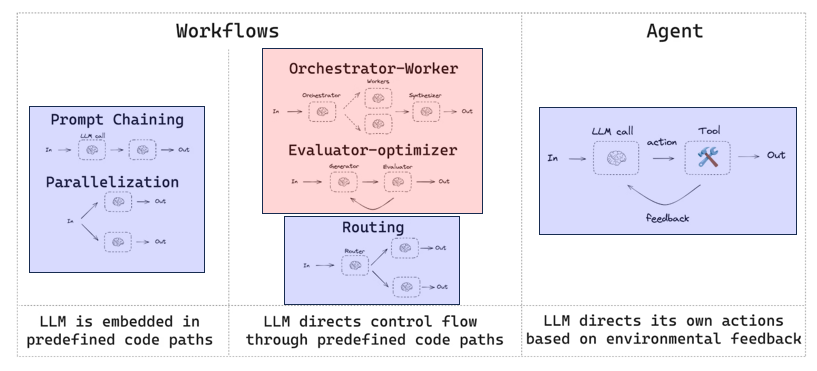

- 함께 살펴본 Workflow 패턴과 Gradio UI를 사용하면, 여러분만의 AI 서비스를 개발할 수 있을 것입니다!

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.